## Введение

Этот проект объединяет несколько задач, связанных с понижением размерности и сингулярным разложением.  
Несмотря на то, что эксперименты проводятся на разных типах данных — разреженных матрицах, изображениях, видео и классических датасетах для визуализации, — все части проекта связаны одной общей идеей: **представить сложные данные в более компактной форме и исследовать, какую полезную структуру можно при этом сохранить или извлечь**.

В рамках проекта рассматриваются как линейные методы (`PCA`, `SVD`, `TruncatedSVD`), так и нелинейные подходы (`t-SNE`, `UMAP`, `LLE`).  
Отдельное внимание уделяется не только визуализации после снижения размерности, но и практическим применениям SVD — компрессии изображений, выделению фоновой компоненты на видео и анализу скрытых представлений объектов в латентном пространстве.

Таким образом, проект показывает, что методы понижения размерности полезны не только как инструмент визуализации, но и как способ сжатия, анализа и выделения структуры в данных.

##### Разница между PCA и SVD

PCA - это метод анализа, а SVD - это математический инструмент, который часто используют для упрощенного счета в PCA, причем PCA работает только с центрированными матрицами.  
PCA находит главные компоненты, позволяет отбрасывать "слабые" направления, тем самым понижая размерность.  
SDV в свою очередь это простой инструмент, математическая теорема линеной алгебры, он не знает не про какие дисперсии, признаки или статистику.  
Коротко говоря, PCA = применение SVD к центрированным данным + статистическая интерпретация. 

### 2.Classification with Sparse Features ###

In [ ]:
import pandas as pd
import numpy as np
import time
import cv2
import matplotlib.pyplot as plt

from umap import UMAP
from scipy import sparse
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.datasets import fetch_openml
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from skimage import data
from skimage.color import rgb2gray
from skimage import io
from glob import glob
from sklearn.utils import shuffle

In [432]:
ratings = pd.read_csv('data/Ratings.csv')
users = pd.read_csv('data/Users.csv')

In [433]:
users = users[(users['Age'] > 6) & (users['Age'] < 105)].dropna()

valid_users_ids = set(users['User-ID'])
ratings = ratings[ratings['User-ID'].isin(valid_users_ids)]

ratings['user_idx'] = ratings['User-ID'].astype('category').cat.codes
ratings['book_idx'] = ratings['ISBN'].astype('category').cat.codes

X = sparse.coo_matrix(
    (ratings['Book-Rating'],
     (ratings['user_idx'], ratings['book_idx']))
)

X = X.tocsr()


In [434]:
user_id = (
    ratings[['User-ID', 'user_idx']]
    .drop_duplicates()
)

user_id = user_id.merge(
    users[['User-ID', 'Age']],
    on='User-ID',
    how='left'
)
user_id = user_id.sort_values('user_idx')
y = user_id['Age'].values

In [435]:
X_train, X_v, y_train, y_v = train_test_split(X, y, test_size=0.3, random_state=21)
X_val, X_test, y_val, y_test = train_test_split(X_v, y_v, test_size=0.5, random_state=21)

In [436]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)


(43201, 283629) (43201,)
(9258, 283629) (9258,)
(9258, 283629) (9258,)


In [ ]:
comparing = pd.DataFrame(columns=['Model','Time','R2'])
def to_compare(model,X_train,y_train,X_val,y_val,name_model):
    start = time.time()
    model.fit(X_train,y_train)
    end = time.time()
    predict = model.predict(X_val)
    comparing.loc[len(comparing)] = [name_model,(end-start),r2_score(y_val,predict)]

In [ ]:
params_ridge = {
    'alpha' : np.linspace(0.1,10000,1000)
}

ridge_search = RandomizedSearchCV(param_distributions = params_ridge,estimator = Ridge(random_state=21), cv = 5, n_iter = 6,random_state=21)
to_compare(ridge_search,X_train,y_train,X_val,y_val,'Ridge_sparse')

In [439]:
comparing

,Model,Time,R2
0,Ridge_sparse,1.300257,0.027028


К сожалению, деревья очень плохо работают со sparse матрицами, поэтому я сделаю срез по трейн датасету, дабы не ждать 20 минут

In [440]:
params_randomforest = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5,8,10,12],
    'min_samples_leaf' : [5,15,25]
}

rf_search = RandomizedSearchCV(param_distributions=params_randomforest,estimator=RandomForestRegressor(random_state=21,n_jobs=-1),cv=5,n_iter=3)
to_compare(rf_search,X_train[:5000],y_train[:5000],X_val,y_val,'Random_forest_sparse')

In [ ]:
svd = TruncatedSVD(n_components=300,random_state=21)

svd.fit(X_train)
X_train_pca = svd.transform(X_train)
X_val_pca = svd.transform(X_val)
X_test_pca = svd.transform(X_test)

umap_model = UMAP(
    n_components=50,
    n_neighbors=15,
    random_state=21
)

In [ ]:
X_train_umap = umap_model.fit_transform(X_train_pca)
X_val_umap   = umap_model.transform(X_val_pca)
X_test_umap  = umap_model.transform(X_test_pca)


In [ ]:
params_ridge = {
    'alpha' : np.linspace(0.1,10000,1000)
}

ridge_search = RandomizedSearchCV(param_distributions = params_ridge,estimator = Ridge(random_state=21), cv = 5, n_iter = 6,random_state=21)
to_compare(ridge_search,X_train_umap,y_train,X_val_umap,y_val,'Ridge_umap')

params_randomforest = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5,8,10,12],
    'min_samples_leaf' : [5,15,25]
}

rf_search = RandomizedSearchCV(param_distributions=params_randomforest,estimator=RandomForestRegressor(random_state=21,n_jobs=-1),cv=5,n_iter=3)
to_compare(rf_search,X_train_umap[:5000],y_train[:5000],X_val_umap,y_val,'Random_forest_umap')

In [ ]:
params_ridge = {
    'alpha' : np.linspace(0.1,10000,1000)
}

ridge_search = RandomizedSearchCV(param_distributions = params_ridge,estimator = Ridge(random_state=21), cv = 5, n_iter = 6,random_state=21)
to_compare(ridge_search,X_train_pca,y_train,X_val_pca,y_val,'Ridge_pca')

params_randomforest = {
    'n_estimators' : [100,200,300],
    'max_depth' : [5,8,10,12],
    'min_samples_leaf' : [5,15,25]
}

rf_search = RandomizedSearchCV(param_distributions=params_randomforest,estimator=RandomForestRegressor(random_state=21,n_jobs=-1),cv=5,n_iter=1)
to_compare(rf_search,X_train_pca[:4000],y_train[:4000],X_val_pca,y_val,'Random_forest_pca')

In [447]:
comparing

,Model,Time,R2
0,Ridge_sparse,1.300257,0.027028
1,Random_forest_sparse,41.932969,0.000017
2,Ridge_umap,0.071479,0.015900
3,Random_forest_umap,53.099529,0.014827
4,Ridge_pca,0.774805,0.008386
5,Random_forest_pca,60.894682,0.038497


Понижение размерности с помощью UMAP, PCA алгоритмов не дали сильных успехов, скорее всего, в нашем сгенерированном признаке просто нет какой-то полезной информации для построения зависимости между таргетом

### 3. Visualizations

В данном задании, X - это матрица изображений, у которой:  
каждая __строка__ - это одно изображение. \
каждый __столбец__ - это пиксель. \
каждое __значение__ - это интенсивноить серого цвета \
Размер картинки 28х28

In [448]:
X, y = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto',return_X_y=True)
y = y.astype(int)

In [449]:
print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

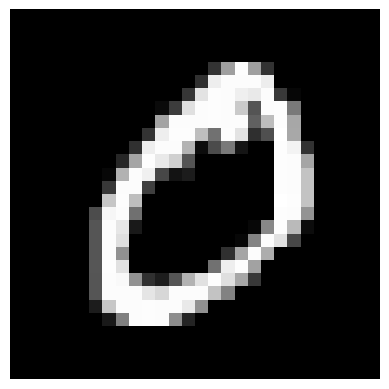

In [450]:
img = X[1]

plt.imshow(img.reshape(28, 28), cmap='gray')
plt.axis('off')


##### Теперь касаемо метрик #####

Для этого задания я выбрал 2 метрики - __Silhouette Score__ и __KNN accuracy в 2D__. 

Вообще, Silhouette Score известна как метрика в кластеризации, но также она применима и в задачах понижения размерности.  \
Если говорить коротко, то Silhouette Score сравнивает расстояние внутри класса и расстояние до других классов. \
Варьируется в диапозоне от -1 до 1. Чем ближе к 1 - тем лучше

Идея, находящаяся в KNN accuracy, состоит в том, что берут ближайшие соседские точки и смотрят, какой класс имеют эти точки. \
На самом деле, мы просто для нашего 2d матрицы высчитываем knn и потом считаем акураси.  
Может показаться, что это неправильная метрика, но на самом деле, это простая оценка наших 2d эмбендингов

In [460]:
df_metrics = pd.DataFrame(columns=['Model','Time','Silhouette_score','KNN_accuracy'])
def compute_metrics(method,X,y,df_metrics,name_model):
    start = time.time()
    X_2d = method.fit_transform(X)
    end = time.time()
    sh_score = silhouette_score(X_2d, y)

    knn = KNeighborsClassifier(n_neighbors=5)
    acc = cross_val_score(knn, X_2d, y, cv=5).mean()
    df_metrics.loc[len(df_metrics)] = [name_model,(end-start),sh_score,acc]
    
    plt.figure(figsize=(8, 6))
    for digit in range(10):
        idx = (y == digit)
        plt.scatter(
            X_2d[idx, 0],
            X_2d[idx, 1],
            s=1,
            label=str(digit)
        )

    plt.legend(loc='upper right')
    plt.title(f"{name_model} on MNIST")
    plt.show()

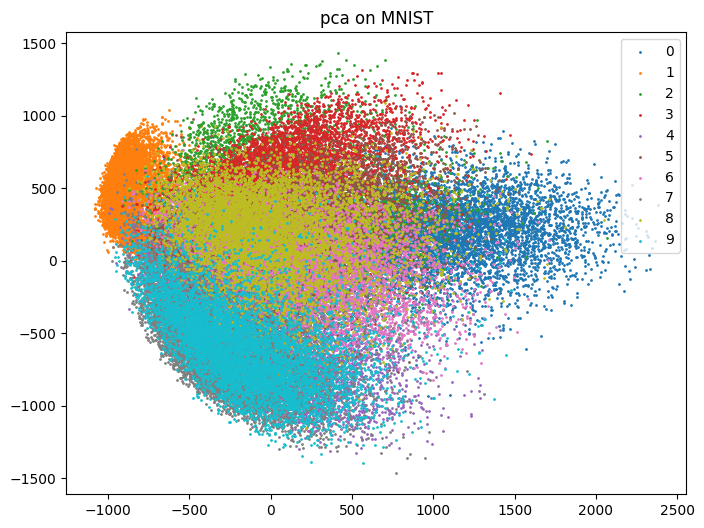

In [461]:
pca = PCA(n_components=2)
compute_metrics(pca,X,y,df_metrics,'pca')

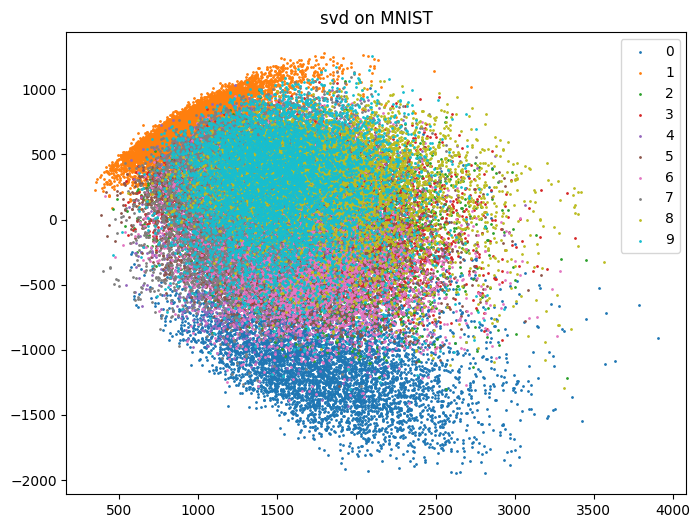

In [462]:
svd = TruncatedSVD(n_components=2)
compute_metrics(svd,X,y,df_metrics,'svd')

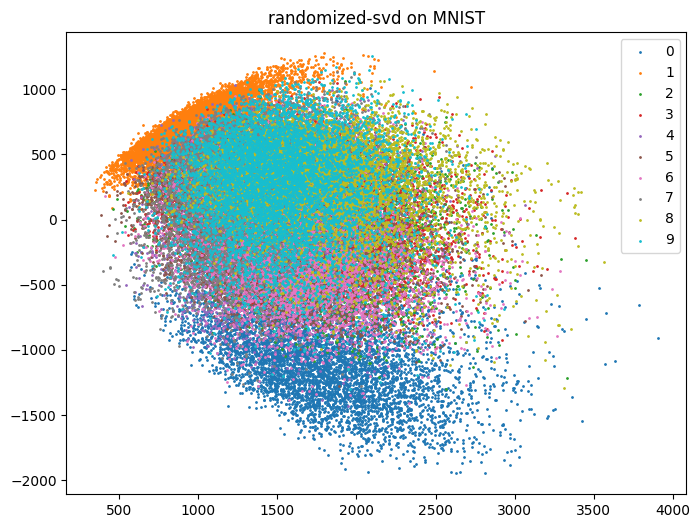

In [463]:
svd_random = TruncatedSVD(algorithm='randomized')
compute_metrics(svd_random,X,y,df_metrics,'randomized-svd')

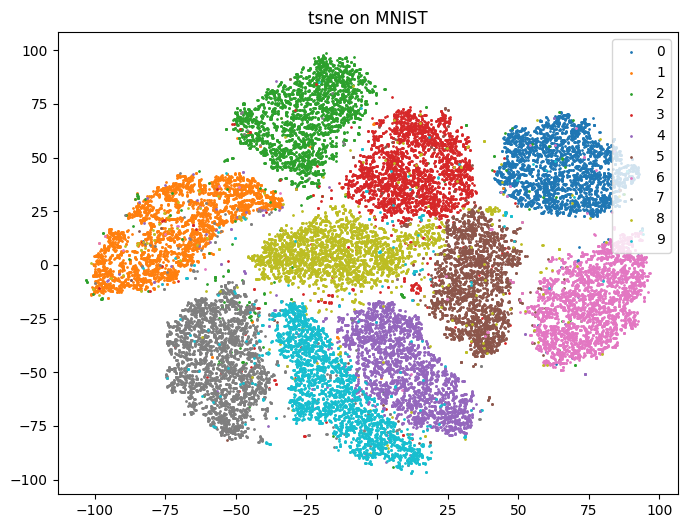

In [464]:
tsne = TSNE(n_components=2)
compute_metrics(tsne,X[:30000],y[:30000],df_metrics,'tsne')

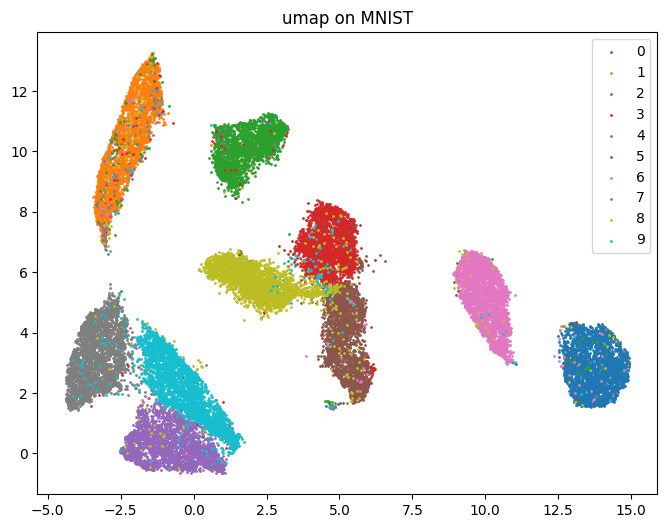

In [465]:
umap_model = UMAP(n_components=2)
compute_metrics(umap_model,X[:30000],y[:30000],df_metrics,'umap')

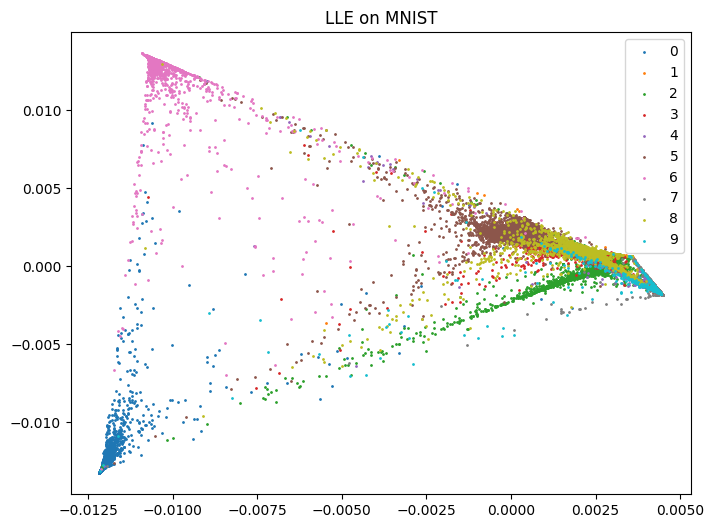

In [466]:
lle = LocallyLinearEmbedding(n_components=2)
compute_metrics(lle,X[:30000],y[:30000],df_metrics,'LLE')

In [467]:
df_metrics

,Model,Time,Silhouette_score,KNN_accuracy
0,pca,0.248142,0.022645,0.415914
1,svd,0.643167,-0.029434,0.301529
2,randomized-svd,0.621098,-0.029431,0.300957
3,tsne,51.665070,0.360344,0.962967
4,umap,6.123609,0.465135,0.951300
5,LLE,65.118298,0.359530,0.893333


По полученным графикам можно сделать вывод, что лучше всего справились алгоритмы нелинейные UMAP и TSNE. \
Если мы обратимся к нашим метрикам, то действительно можем увидеть, что 2 вышеперечисленные алгоритма имеют лучший скор

### 4. Image compression using SVD

В этой части мы посмотрим, как SVD разложение применяют на самом деле. \
Мы возьмем три фотографии и с помощью svd понизим ранги, и посмотрим на качество фото

In [468]:
def image_show(image, nrows=1, ncols=1, cmap='gray'):
    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 14))
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    return fig, ax

In [469]:
images = [
    rgb2gray(data.astronaut()),
    rgb2gray(data.coffee()),
    data.camera()
]

images = [image.astype(float) for image in images]
ranks = [5,10,20,30,50,100]

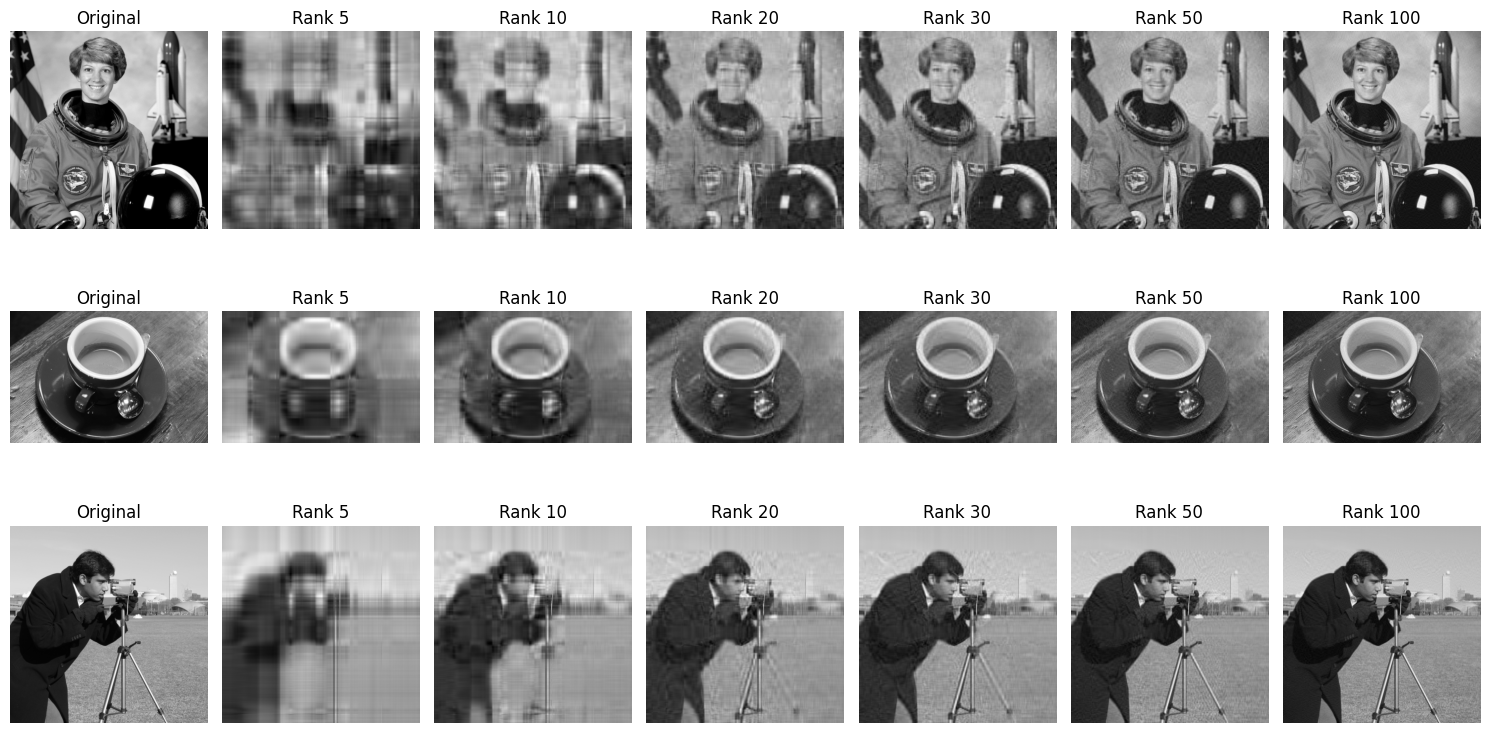

In [470]:
fig, axes = plt.subplots(len(images), len(ranks) + 1, figsize=(15, 8))

def compress_svd(img, k):
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    reconstructed = U[:, :k]@np.diag(S[:k])@Vt[:k, :]
    return reconstructed, S

for row_idx, img in enumerate(images):
    ax_original = axes[row_idx, 0]
    ax_original.imshow(img, cmap='gray')
    ax_original.set_title('Original')
    ax_original.axis('off')
    
    for col_idx, k in enumerate(ranks):
        img_new, S = compress_svd(img, k)
        
        ax = axes[row_idx, col_idx + 1]
        ax.imshow(img_new, cmap='gray')
        ax.set_title(f"Rank {k}")
        ax.axis('off')

plt.tight_layout()
plt.show()

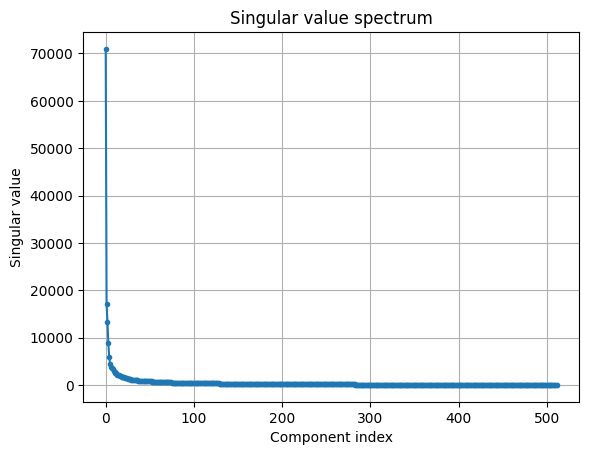

In [471]:
plt.plot(S, marker='o',markersize=3)
plt.xlabel("Component index")
plt.ylabel("Singular value")
plt.title("Singular value spectrum")
plt.grid(True)
plt.show()


В принципе, схожие черты начинают уже виднеться при 5 ранге, а оригинал начинает проявляться уже с 50 рангом

Теперь поговорим о таком понятии, как __Explained Variance__. 
$$ ExplVar(k) = \frac{∑_{i=1}^k σ_i^2}{∑_{i} σ_i^2} $$
Он чем-то похож на обычную дисперсию, только вместо дисперсии чаще применяют именно эту метрику.  
ExplVar показывает, какую долю информации изображения мы сохранили, если оставили первые k компонент. \
То есть, повышая количество k компонент мы стремимся к 100%, то есть мы стремимся к оригиналу. \
Обычно, в изображениях в первых компонентах находиться больше всего информации, математическими словами - это квадрат дисперсии.

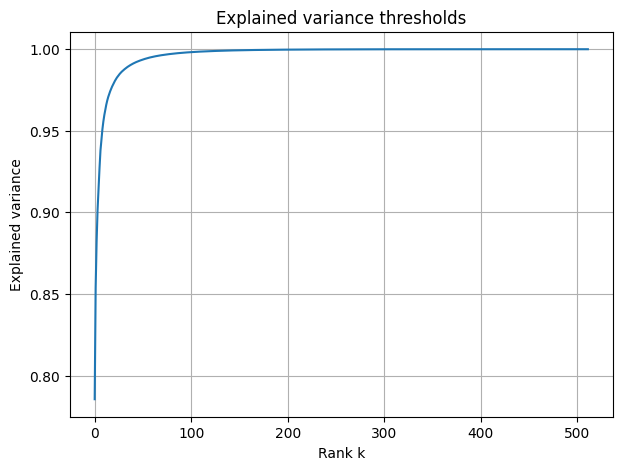

k for 90%: 4
k for 95%: 9
k for 99%: 38


In [472]:
def explained_variance(img):
    U, S, Vt = np.linalg.svd(img, full_matrices=False)
    variance_2 = S**2
    ev = np.cumsum(variance_2) / np.sum(variance_2)
    return ev, S

ev, S = explained_variance(images[0])
plt.figure(figsize=(7,5))
plt.plot(ev)
plt.xlabel("Rank k")
plt.ylabel("Explained variance")
plt.title("Explained variance thresholds")
plt.grid(True)
plt.show()

k90 = np.searchsorted(ev, 0.90) + 1
k95 = np.searchsorted(ev, 0.95) + 1
k99 = np.searchsorted(ev, 0.99) + 1
print(f"k for 90%: {k90}\nk for 95%: {k95}\nk for 99%: {k99}")


### 5. Background detection using SVD

#### Применение SVD к видео
Первая мысль, которая может возникать - "Как мы можем применить SDV-разложение для видео?" \
Видео состоит из кадров, а кадр - это изображение, которое как раз может представляться в виде вектора, тогда получается, что видео мы также можем сделать матрицей, а значит можем сдлеать SVD разложение.  
Кстати, касаемо фона, каким образом мы можем оставить один фон без машин? \
Ответ строиться на выводе из предыдущих параграфов. Фон - статичный, а машины - нет.  
Отсюда ключевая мысль - фон содержится в низкоранговой части, а более мелкие детали(машины) - это высокоранговая часть. 

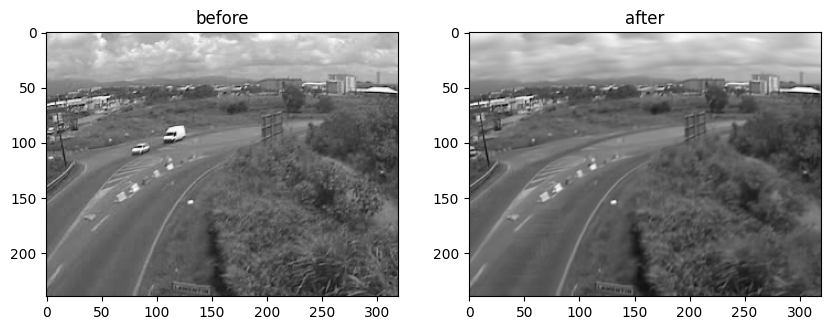

In [474]:
cap = cv2.VideoCapture("data/Video_008.avi")
frames = []
frame_count = 0

while cap.isOpened() and frame_count < 100:
    ret, frame = cap.read()
    if not ret:
        break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray_frame.flatten())
    frame_count+=1

cap.release()

X = np.array(frames).T
U, S, Vt = np.linalg.svd(X, full_matrices=False)

k=3
background_vec = U[:,:k] @ np.diag(S[:k]) @ Vt[:k,:]

background_frame_flat = background_vec[:,0]

height, width = gray_frame.shape
background_img = background_frame_flat.reshape(height,width)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[:,0].reshape(height,width), cmap='gray')
plt.title('before')

plt.subplot(1,2,2)
plt.imshow(background_img,cmap='gray')
plt.title('after')

plt.show()

Фон уже четко виден при самом 1 ранге, при ранге 5 уже начинаются виднеться машины

### 5. Изменение эмоций на лице

В этой части я попробую изменить улыбку на грусть и наоборот. Буду я это делать с помощью PCA алгоритма.

In [475]:
files_sad = glob('data/sad/*.jpg')
files_happy = glob('data/happy/*.jpg')

X = []
y = []

for file in files_sad:
    image = io.imread(file)
    X.append(image.flatten())
    y.append('sad')

for file in files_happy:
    image = io.imread(file)
    X.append(image.flatten())
    y.append('happy')

X = np.array(X)
y = np.array(y)

X, y = shuffle(X,y, random_state=21)

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

model= PCA(n_components=100)
X_pca = model.fit_transform(X)

X_pca_happy = X_pca[y=="happy"]
X_pca_sad = X_pca[y=="sad"]

mean_happy = X_pca_happy.mean(axis=0)
mean_sad = X_pca_sad.mean(axis=0)

In [478]:
emotion_vector = mean_happy - mean_sad

In [479]:
z_sad = X_pca_sad[1]
alpha = 10.0  #сила изменения
z_smile = z_sad + alpha*emotion_vector

In [480]:
#обратный pca
x_smile_scaled = model.inverse_transform(z_smile)
#обратный scaler
x_smile = scaler.inverse_transform(x_smile_scaled.reshape(1, -1))


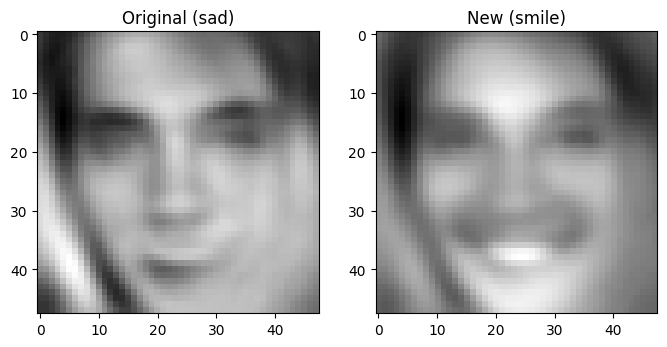

In [481]:
orig_face = scaler.inverse_transform(
    model.inverse_transform(z_sad).reshape(1, -1)
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig_face.reshape(48,48), cmap="gray")
plt.title("Original (sad)")

plt.subplot(1,2,2)
plt.imshow(x_smile.reshape(48,48), cmap="gray")
plt.title("New (smile)")

plt.show()


In [482]:
z_happy = X_pca_happy[49]
alpha = 5
z_sadder = z_happy - alpha*emotion_vector

In [483]:
#обратный pca
x_sad_scaled = model.inverse_transform(z_sadder)
#обратный scaler
x_sad = scaler.inverse_transform(x_sad_scaled.reshape(1, -1))


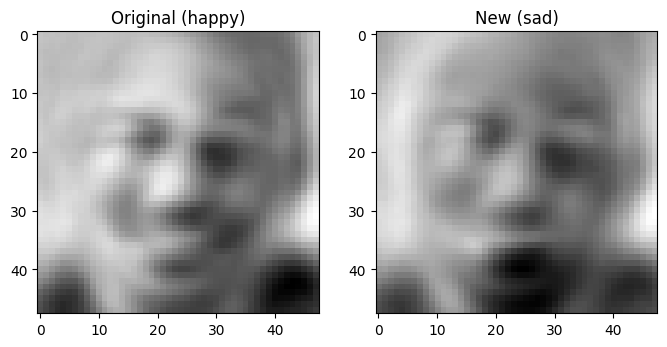

In [484]:
orig_face = scaler.inverse_transform(
    model.inverse_transform(z_happy).reshape(1, -1)
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(orig_face.reshape(48,48), cmap="gray")
plt.title("Original (happy)")

plt.subplot(1,2,2)
plt.imshow(x_sad.reshape(48,48), cmap="gray")
plt.title("New (sad)")

plt.show()


В принципе, вышло очень даже неплохо, но мы должны понимать, что идеально конечно же не будет из-за 100 компонент на PCA. \
Также возможно, что линейная модель здесь не очень хорошо справляется и можно было попробовать взять другой нелиненый метод